In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, optimize

https://stackoverflow.com/questions/79878768/fitting-model-to-data-using-curve-fit-in-python

In [2]:
t = np.linspace(0, 15, 300)

In [3]:
def model(t, y, Lambda, beta, mu, gamma, tau, w, alpha, Gamma, pi):
    S, E, I, T, R = y
    dSdt = Lambda - beta * I * S - mu * S
    dEdt = beta * I * S - (gamma + tau + mu) * E
    dIdt = gamma * E + w * R - (alpha + Gamma + mu) * I
    dTdt = alpha * I + tau * E - (mu + pi) * T
    dRdt = pi * T  - (w + mu) * R
    return np.array([dSdt, dEdt, dIdt, dTdt, dRdt])

In [4]:
y0 = [1e5, 1.6e4, 1e2, 2e2, 3e2]

In [5]:
p0 = [55730., 0.00062, 0.0174, 0.5, 0.37, 0.7, 0.37, 0.00068, 0.8]

In [6]:
def solver(t, Lambda, beta, mu, gamma, tau, w, alpha, Gamma, pi, *y0):
    solution = integrate.solve_ivp(model, [t[0], t[-1]], y0=y0, t_eval=t, method="LSODA", args=(Lambda, beta, mu, gamma, tau, w, alpha, Gamma, pi))
    return solution.y

In [7]:
np.random.seed(123456)
y = solver(t, *p0, *y0)

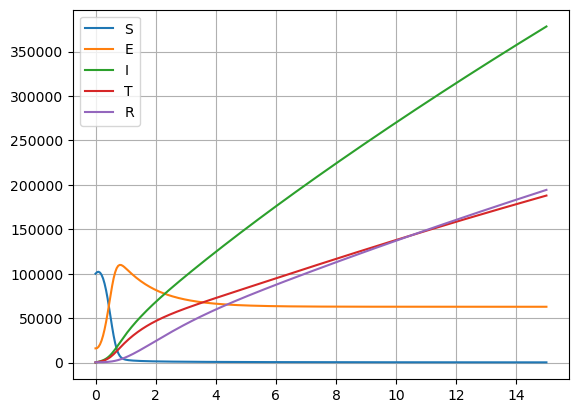

In [9]:
fig, axe = plt.subplots()
axe.plot(t, y.T)
axe.legend(["S", "E", "I", "T", "R"])
axe.grid()